In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import torch
import CustomModules.A_CAE as A_CAE
from datasets import load_dataset
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from torch.utils.data import Dataset
from torchvision import datasets

In [5]:
mnist = datasets.MNIST(root='data', train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=None)

In [6]:

X_data = mnist.data.float()
X_data_test = mnist_test.data.float()

X_data = X_data / 255.0
X_data_test = X_data_test / 255.0

X_data = X_data.reshape(-1, 28*28)
X_data_test = X_data_test.reshape(-1, 28*28)

X_loader = torch.utils.data.DataLoader(X_data, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_data_test, batch_size=1024, shuffle=False)

In [7]:
cae = A_CAE.CAE(784, 32, 10, 128, 128, 10, 5)
A_CAE.train_cae(num_epochs=30, x_train_loader=X_loader, network=cae, device=device)

100%|██████████| 30/30 [00:41<00:00,  1.38s/it]


[(tensor([ 9.6790, 10.3539, 11.1752,  ...,  9.8396, 11.8531, 11.6503],
         device='cuda:0', grad_fn=<MinBackward0>),
  tensor([1.6316, 1.6312, 1.6334,  ..., 1.6311, 1.6345, 1.6342], device='cuda:0',
         grad_fn=<NegBackward0>),
  tensor(0.1147, device='cuda:0', grad_fn=<MseLossBackward0>),
  tensor(20.1487, device='cuda:0', grad_fn=<AddBackward0>)),
 (tensor([ 6.9705, 11.0173, 10.5721,  ...,  7.7294,  8.4608,  6.4736],
         device='cuda:0', grad_fn=<MinBackward0>),
  tensor([1.6327, 1.6360, 1.6289,  ..., 1.6297, 1.6333, 1.6274], device='cuda:0',
         grad_fn=<NegBackward0>),
  tensor(0.1130, device='cuda:0', grad_fn=<MseLossBackward0>),
  tensor(19.3100, device='cuda:0', grad_fn=<AddBackward0>)),
 (tensor([ 6.3046,  7.2445,  9.1232,  ...,  7.3687,  8.0217, 10.6870],
         device='cuda:0', grad_fn=<MinBackward0>),
  tensor([1.6252, 1.6281, 1.6286,  ..., 1.6267, 1.6310, 1.6280], device='cuda:0',
         grad_fn=<NegBackward0>),
  tensor(0.1163, device='cuda:0', grad

In [8]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.encode_decode(batch).detach().numpy()



In [9]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.decode(cae.encode(batch)).detach().numpy()

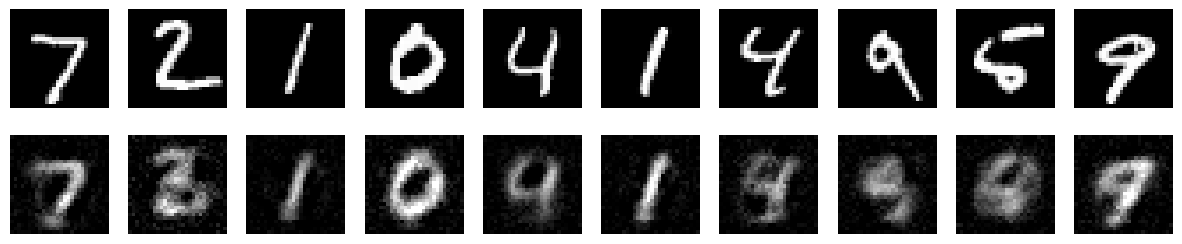

In [10]:

#plot both batch and reconstructed images
fig, axs = plt.subplots(2, 10, figsize=(15, 3))

for i, (image, ax) in enumerate(zip(batch, axs[0])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

for i, (image, ax) in enumerate(zip(reconstructed, axs[1])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

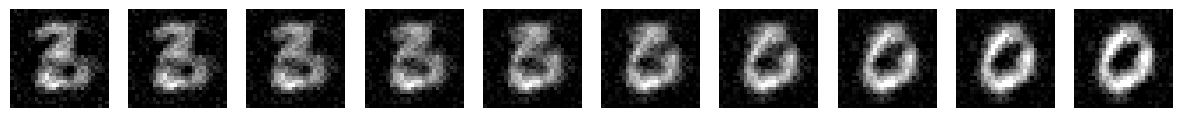

In [11]:


start_encoded = cae.encode(batch[1].unsqueeze(0))
end_encoded = cae.encode(batch[3].unsqueeze(0))
interpolated = torch.linspace(0, 1, steps=10).unsqueeze(1) * end_encoded + (1 - torch.linspace(0, 1, steps=10).unsqueeze(1)) * start_encoded
decoded_interpolated = cae.decode(interpolated).detach().numpy()
#plot
fig, axs = plt.subplots(1, 10, figsize=(15, 3))
for i, (image, ax) in enumerate(zip(decoded_interpolated, axs)):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")



In [12]:

from CustomModules.util import farthest_point_sample


points = torch.randn(500, 3)

sampled, idx = farthest_point_sample(points, 3)

print(sampled)
print(idx)

[[-0.11105742 -1.34463    -0.4165722 ]
 [-2.5256753  -0.39021042  2.9594898 ]
 [-0.4338827   2.8467286  -0.1984158 ]]
[  0 473 418]
